In [156]:
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

# Import and Clean Data

In [10]:
data = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/u.data',  sep='\t', header=None)
data

,0,1,2,3
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [12]:
#user id | item id | rating | timestamp
columns_renamed = ['user_id', 'item_id', 'rating', 'timestamp']
data.columns = columns_renamed
data

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [17]:
data.isna().sum()

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

In [19]:
data.dtypes

user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

In [20]:
(data == 0).sum()

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

# Similarity Measures

## Create the matrix

In [40]:
data['user_id'].nunique()
data['item_id'].nunique()

1682

In [141]:

# thus I want a matrix with 943 rows, 1682 columns
user_ids = sorted(data['user_id'].unique())
item_ids = sorted(data['item_id'].unique())

# matrix[i][j] is rating for person i, movie j
print(user_ids[0], user_ids[942])
print(item_ids[0], item_ids[1581])
            
# map to indexes
user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_id_to_index = {item_id: idx for idx, item_id in enumerate(item_ids)}

# create empty matrix
matrix = np.zeros((len(user_ids), len(item_ids)))

# fill matrix
for row in data.itertuples():
    user_idx = user_id_to_index[row.user_id]
    item_idx = item_id_to_index[row.item_id]
    matrix[user_idx][item_idx] = row.rating

print(len(matrix))
print(len(matrix[0]))

1 943
1 1582
943
1682


In [105]:
# Can run this to get item-item similarity measures
# matrix = matrix.T
# len(matrix[0])

943

## Without Normalization

In [151]:
## Cosine
cos_sim_matrix = cosine_similarity(matrix)

## Jaccard
# convert the matrix to unary data
# >=3 --> like, <=2 --> dislike
binary_matrix = np.where(matrix >= 3, 1, 0)

# def jaccard(row_1, row_2):
#     intersect = set(matrix[row_1]) & set(matrix[row_2])
#     union = set(matrix[row_1]) | set(matrix[row_2])
#     return len(intersect)/float(len(union))

jaccard_matrix = 1 - pairwise_distances(binary_matrix, metric='jaccard')

## Pearson
pearson_matrix = np.corrcoef(matrix)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [160]:
print("non normalized averages:")
print(f"average cosine similarity: {np.mean(cos_sim_matrix)}")
print(f"average jaccard similarity: {np.mean(jaccard_matrix)}")
print(f"average pearson similarity: {np.mean(pearson_matrix)}")

non normalized averages:
average cosine similarity: 0.1729423754100594
average jaccard similarity: 0.07871291572381608
average pearson similarity: 0.1343067237231004


## Normalized

In [144]:
## Compute normalization by subtracting the mean of the value from the ratings

# compute the row means
row_means = np.true_divide(matrix.sum(1), (matrix != 0).sum(1))

# Step 2: Subtract row mean only where rating is non-zero
norm_matrix = matrix.copy().astype(float)
for i in range(len(norm_matrix)):
    for j in range(len(norm_matrix[0])):
        if norm_matrix[i, j] != 0:
            norm_matrix[i, j] -= row_means[i]


In [145]:
norm_matrix.shape[0]
norm_matrix.shape[1]

1682

In [ ]:
## Cosine - user to user similarities
cos_norm_matrix = cosine_similarity(norm_matrix)

## Jaccard - user to user similarities
# convert the matrix to unary data
# this is measuring like vs dislike, whereas unnormalized 
binary_matrix = np.where(norm_matrix > 0, 1, 0)
jaccard_norm_matrix = 1 - pairwise_distances(binary_matrix, metric='jaccard')

## Pearson - user to user similarities
pearson_norm_matrix = np.corrcoef(norm_matrix)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [154]:
print("Normalized Averages")
print(f"average cosine similarity: {np.mean(cos_norm_matrix)}")
print(f"average jaccard similarity: {np.mean(jaccard_norm_matrix)}")
print(f"average pearson similarity: {np.mean(pearson_norm_matrix)}")

Normalized Averages
average cosine similarity: 0.024392118462536312
average jaccard similarity: 0.058812436385150435
average pearson similarity: 0.024392118462536312


# Visualize Data

## Users

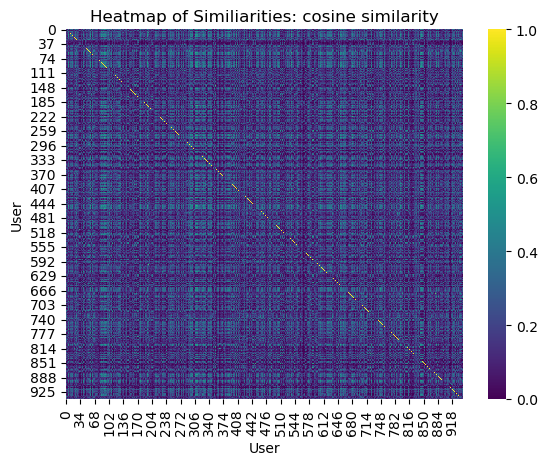

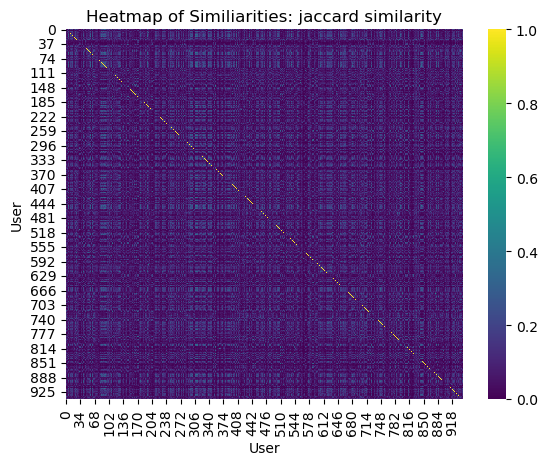

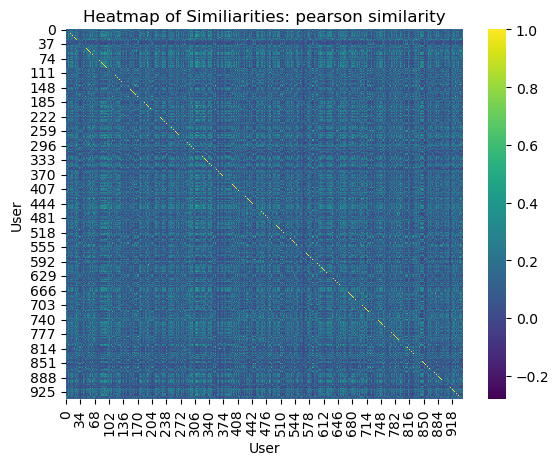

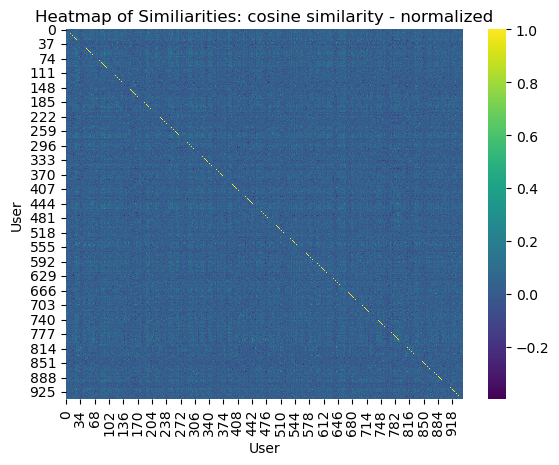

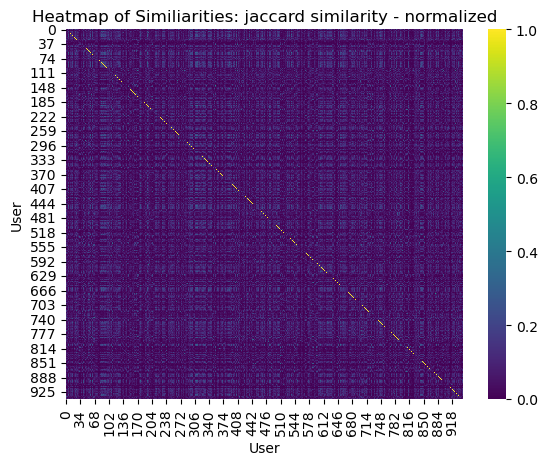

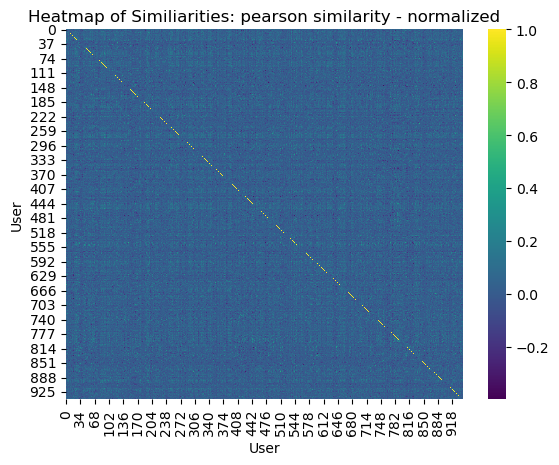

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt


list_matrices = [cos_sim_matrix, jaccard_matrix, pearson_matrix, cos_norm_matrix, jaccard_norm_matrix, pearson_norm_matrix]
list_matrix_titles = ['cosine similarity', 'jaccard similarity', 
'pearson similarity', 'cosine similarity - normalized', 'jaccard similarity - normalized', 'pearson similarity - normalized']

for i in range(len(list_matrices)):
    sns.heatmap(list_matrices[i], cmap='viridis', annot=False)

    plt.title(f"Heatmap of Similiarities: {list_matrix_titles[i]}")
    plt.xlabel("User")
    plt.ylabel("User")
    plt.show()

